# EDA: `orders`

Разведочный анализ таблицы `orders` из базы данных Olist.


### Импорты

In [1]:
import pandas as pd

import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from sqlalchemy.engine import URL

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

True

### Конфигурация

In [3]:
USERNAME = os.getenv("DB_USERNAME")
PASSWORD = os.getenv("DB_PASSWORD")
HOST = os.getenv("DB_HOST")
PORT = os.getenv("DB_PORT")
DATABASE = os.getenv("DB_NAME")

url = URL.create(
    drivername="postgresql+psycopg2",
    username=USERNAME,
    password=PASSWORD,
    host=HOST,
    port=PORT,
    database=DATABASE,
)

In [4]:
connection = create_engine(url=url)

## Анализ данных


In [5]:
read_sql_query = "SELECT * FROM orders"
df = pd.read_sql(sql=read_sql_query, con=connection)

In [6]:
df.head()

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_id
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,9ef432eb6251297304e76186b10a928d
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,b0830fb4747a6c6d20dea0b8c802d7ef
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,41ce2a54c0b03bf3443c3d931a367089
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,f88197465ea7920adcdbec7375364d82
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,8ab97904e6daea8866dbdbc4fb7aad2c


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   order_status                   99441 non-null  str           
 2   order_purchase_timestamp       99441 non-null  datetime64[us]
 3   order_approved_at              99281 non-null  datetime64[us]
 4   order_delivered_carrier_date   97658 non-null  datetime64[us]
 5   order_delivered_customer_date  96476 non-null  datetime64[us]
 6   order_estimated_delivery_date  99441 non-null  datetime64[us]
 7   customer_id                    99441 non-null  str           
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [8]:
df.describe(include='all')

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_id
count,99441,99441,99441,99281,97658,96476,99441,99441
unique,99441,8,NaN,NaN,NaN,NaN,NaN,99441
top,e481f51cbdc54678b7cc49136f2d6af7,delivered,NaN,NaN,NaN,NaN,NaN,9ef432eb6251297304e76186b10a928d
freq,1,96478,NaN,NaN,NaN,NaN,NaN,1
mean,NaN,NaN,2017-12-31 08:43:12.776581,2017-12-31 18:35:24.098800,2018-01-04 21:49:48.138278,2018-01-14 12:09:19.035542,2018-01-24 03:08:37.730111,NaN
min,NaN,NaN,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,NaN
25%,NaN,NaN,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.250000,2017-09-25 22:07:22.250000,2017-10-03 00:00:00,NaN
50%,NaN,NaN,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00,NaN
75%,NaN,NaN,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.250000,2018-05-25 00:00:00,NaN
max,NaN,NaN,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,NaN


In [9]:
df.memory_usage(deep=True)

Index                                132
order_id                         8054721
order_status                     5765932
order_purchase_timestamp          795528
order_approved_at                 795528
order_delivered_carrier_date      795528
order_delivered_customer_date     795528
order_estimated_delivery_date     795528
customer_id                      8054721
dtype: int64

In [10]:
first_date = df["order_purchase_timestamp"].min()
last_date = df["order_purchase_timestamp"].max()

duration = last_date - first_date

print(f"Дата первого заказа: {first_date}\n"
      f"Дата последнего заказа: {last_date}\n"
      f"Временной отрезок торговли: {duration}")

Дата первого заказа: 2016-09-04 21:15:19
Дата последнего заказа: 2018-10-17 17:30:18
Временной отрезок торговли: 772 days 20:14:59


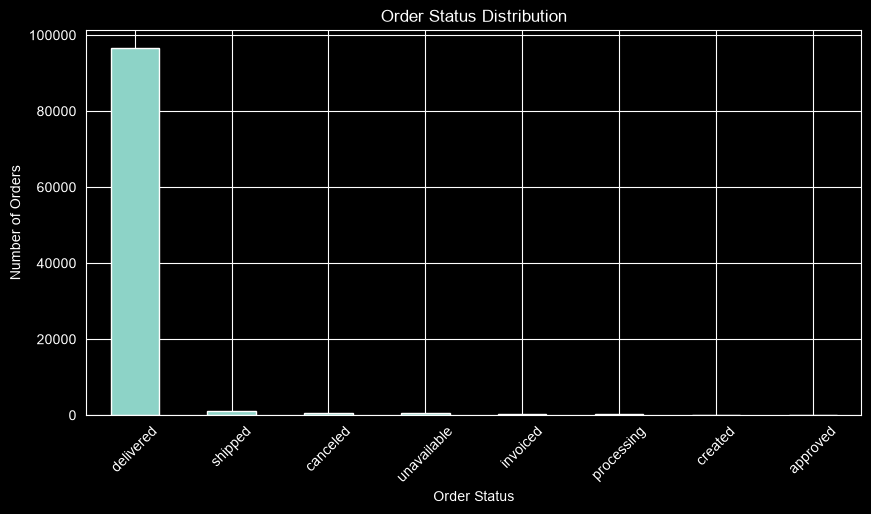

In [11]:
df["order_status"].value_counts().plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

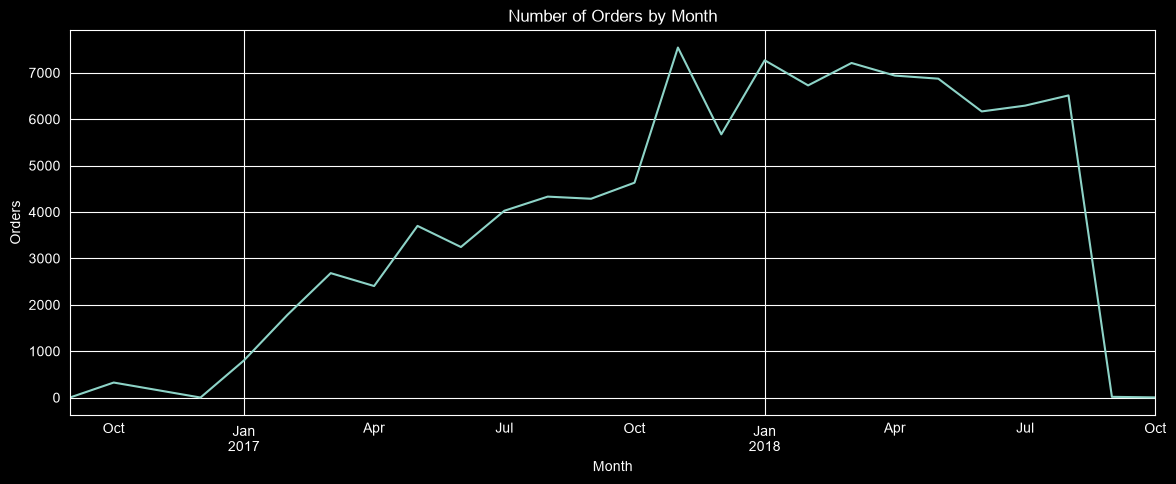

In [12]:
df["purchase_month"] = (
    df["order_purchase_timestamp"]
    .dt.to_period("M")
)

orders_by_month = (
    df.groupby("purchase_month")
    .size()
)

orders_by_month.plot(
    figsize=(14, 5)
)

plt.title("Number of Orders by Month")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.show()

In [13]:
df["delivery_days"] = (df["order_delivered_customer_date"] - df["order_purchase_timestamp"]).dt.total_seconds() / 86400

print('Статистика по дням доставки')
df["delivery_days"].describe()

Статистика по дням доставки


count    96476.000000
mean        12.558702
std          9.546530
min          0.533414
25%          6.766403
50%         10.217755
75%         15.720327
max        209.628611
Name: delivery_days, dtype: float64

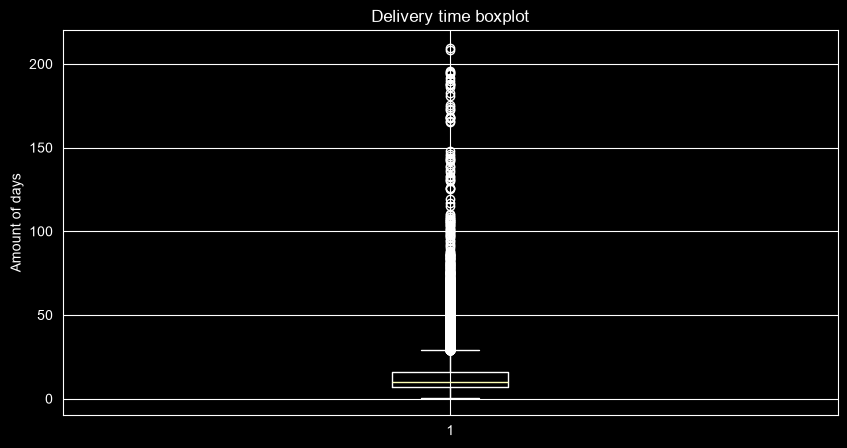

In [14]:
plt.figure(figsize=(10, 5))

plt.boxplot(df["delivery_days"].dropna())

plt.title("Delivery time boxplot")
plt.ylabel("Amount of days")

plt.show()

In [15]:
delivery_delay_days = df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
delivery_delay_days.dropna(inplace=True)
delivery_delay_days = delivery_delay_days.dt.days

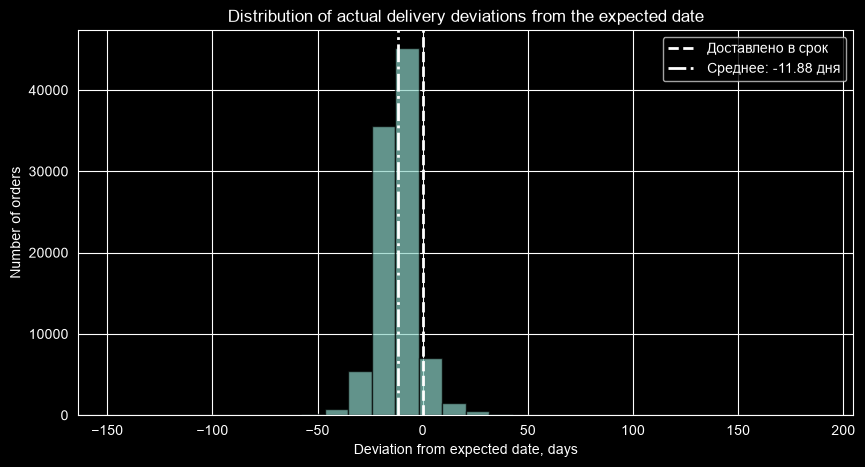

In [16]:
plt.figure(figsize=(10, 5))

plt.hist(
    delivery_delay_days,
    bins=30,
    edgecolor="black",
    alpha=0.7
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2,
    label="Доставлено в срок"
)

mean_delay = delivery_delay_days.mean()

plt.axvline(
    mean_delay,
    linestyle="-.",
    linewidth=2,
    label=f"Среднее: {mean_delay:.2f} дня"
)

plt.xlabel("Deviation from expected date, days")
plt.ylabel("Number of orders")
plt.title("Distribution of actual delivery deviations from the expected date")
plt.legend()

plt.show()

In [17]:
status = delivery_delay_days.apply(lambda x: 'Early' if x < 0 else ('Late' if x > 0 else 'On time') )
status = status.value_counts()

values = status.values
labels = status.index

total = values.sum()
percentages = values / total * 100

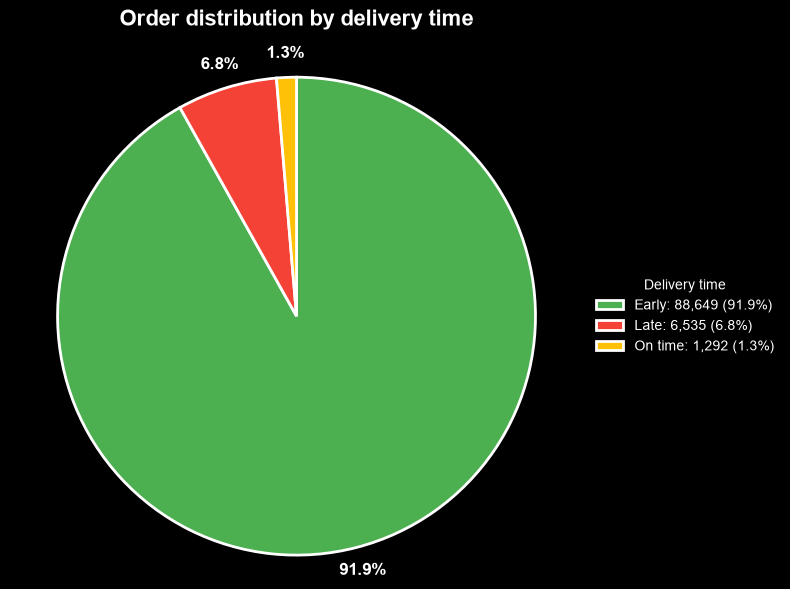

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))

color_map = {
    "Early": "#4CAF50",
    "On time": "#FFC107",
    "Late": "#F44336"
}

colors = [
    color_map[label]
    for label in labels
]

wedges, texts, autotexts = ax.pie(
    values,
    labels=None,
    colors=colors,
    autopct=lambda pct: f"{pct:.1f}%",
    startangle=90,
    counterclock=False,
    pctdistance=1.1,
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 2
    }
)

for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(12)
    autotext.set_fontweight("bold")

ax.set_title(
    "Order distribution by delivery time",
    fontsize=16,
    fontweight="bold",
    pad=20
)

legend_labels = [
    f"{label}: {value:,} ({pct:.1f}%)"
    for label, value, pct in zip(labels, values, percentages)
]

ax.legend(
    wedges,
    legend_labels,
    title="Delivery time",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=False
)

ax.axis("equal")

plt.tight_layout()
plt.show()